In [108]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from astropy.io import fits
import sys
sys.path.insert(0, str(Path('..').resolve()))
from scripts.common import add_galactic, mollweide_scatter as _mws

FILE_PATH = Path('../data/des/DES-SN5YR/4_DISTANCES_COVMAT/DES-Dovekie_HD.csv')
METADATA_PATH = Path('../data/des/DES-SN5YR/4_DISTANCES_COVMAT/DES-Dovekie_Metadata.csv')

survey_names = {5: "Low-z", 10: "DES", 63: "CFA3S", 64: "CFA3K",
                65: "CFA4p2", 66: "CFA4p3", 150: "FOUND"}

survey_styles = {
    'DES':    {'color': '#1f77b4', 'marker': 'o'},
    'Low-z':  {'color': '#ff7f0e', 'marker': 's'},
    'CFA3S':  {'color': '#2ca02c', 'marker': '^'},
    'CFA3K':  {'color': '#d62728', 'marker': 'D'},
    'CFA4p2': {'color': '#9467bd', 'marker': 'v'},
    'CFA4p3': {'color': '#8c564b', 'marker': 'p'},
    'FOUND':  {'color': '#e377c2', 'marker': '*'},
    'Other':  {'color': '#aaaaaa', 'marker': 'x'},
}

def mollweide_scatter(ax, lon, lat, groups, title):
    _mws(ax, lon, lat, groups, survey_styles, title)

In [101]:
df = pd.read_csv(FILE_PATH, sep=r'\s+', comment='#')

keep = ['CID', 'zHEL', 'zHELERR', 'zCMB', 'zCMBERR', 'zHDERR',
        'MWEBV', 'HOST_RA', 'HOST_DEC', 'HOST_ANGSEP', 'HOST_DDLR',
        'HOST_LOGMASS', 'HOST_LOGMASS_ERR', 'HOST_LOGSFR', 'HOST_LOGSFR_ERR',
        'HOST_COLOR', 'HOST_LOGsSFR', 'HOST_LOGsSFR_ERR',
        'PKMJD', 'PKMJDERR', 'x1', 'x1ERR', 'c', 'cERR', 'mB', 'mBERR',
        'x0', 'x0ERR', 'COV_x1_c', 'COV_x1_x0', 'COV_c_x0',
        'NDOF', 'FITCHI2', 'FITPROB',
        'MU', 'MUMODEL', 'MUERR', 'MUERR_RENORM', 'MUERR_RAW', 'MURES', 'MUPULL',
        'biasCor_mu', 'biasCorErr_mu', 'biasCor_nevt', 'IDSAMPLE', 'IZBIN']
meta = pd.read_csv(METADATA_PATH, comment='#', sep=r'\s+')
meta_cols = [c for c in keep if c in meta.columns and c != 'CID']
meta = meta[["CID"] + meta_cols]
existing_cols = [c for c in meta.columns if c in df.columns and c != 'CID']
df = df.merge(meta.drop(columns=existing_cols), on='CID', how='left')

fits_paths = [
    '../data/des/DES-SN5YR/0_DATA/DES-SN5YR_DES/DES-SN5YR_DES_HEAD.FITS',
    '../data/des/DES-SN5YR/0_DATA/DES-SN5YR_Foundation/DES-SN5YR_Foundation_HEAD.FITS.gz',
    '../data/des/DES-SN5YR/0_DATA/DES-SN5YR_LOWZ/DES-SN5YR_LOWZ_HEAD.FITS.gz',
]

def decode_bytes(v):
    return v.decode().strip() if isinstance(v, bytes) else str(v).strip()

all_fits = []
for fp in fits_paths:
    with fits.open(fp) as hdul:
        d = hdul[1].data
        cols = d.columns
        snid = [decode_bytes(r) for r in d["SNID"]] if "SNID" in cols.names else [decode_bytes(r) for r in d["CID"]]
        ra = d["RA"].astype(np.float64) if "RA" in cols.names else np.full(len(d), np.nan)
        dec = d["DEC"].astype(np.float64) if "DEC" in cols.names else np.full(len(d), np.nan)
        pdf = pd.DataFrame({"SNID": snid, "RA": ra, "DEC": dec})
        all_fits.append(pdf)
all_fits = pd.concat(all_fits, ignore_index=True)
merged = meta.merge(all_fits, left_on="CID", right_on="SNID", how="left")
df = df.merge(merged[["CID", "RA", "DEC"]], on="CID", how="left")

df_refined = df[(df["HOST_DEC"] >= -90) & (df["HOST_RA"] >= 0)].copy()

df_refined["l"], df_refined["b"] = add_galactic(df_refined["HOST_RA"], df_refined["HOST_DEC"])
df["l"], df["b"] = add_galactic(df["RA"], df["DEC"])

df["survey_name"] = df["IDSURVEY"].map(survey_names).fillna("Other")
df_refined["survey_name"] = df_refined["IDSURVEY"].map(survey_names).fillna("Other")

print("\nSurvey distribution:")
for sid, cnt in df["IDSURVEY"].value_counts().sort_index().items():
    name = survey_names.get(sid, f"Survey {sid}")
    print(f"  {name:15s} (ID {sid:3d}): {cnt:4d} SNe")
print(f"\nTotal: {len(df)} SNe, {df["CID"].nunique()} unique")
print(f"Host coords available: {len(df_refined)} / {len(df)}")
print(f"SN RA/DEC from FITS: {df["RA"].notna().sum()} / {len(df)}")
print(f"Redshift range: {df["zHD"].min():.4f} - {df["zHD"].max():.4f}")

df.head()


Survey distribution:
  Low-z           (ID   5):    8 SNe
  DES             (ID  10): 1623 SNe
  CFA3S           (ID  63):   16 SNe
  CFA3K           (ID  64):   31 SNe
  CFA4p2          (ID  65):   22 SNe
  CFA4p3          (ID  66):    3 SNe
  FOUND           (ID 150):  117 SNe

Total: 1820 SNe, 1820 unique
Host coords available: 1623 / 1820
SN RA/DEC from FITS: 1820 / 1820
Redshift range: 0.0251 - 1.1442


,VARNAMES:,CID,IDSURVEY,zHD,zHEL,MU,MUERR,MUERR_VPEC,MUERR_SYS,PROBIA_BEAMS,...,biasCor_mu,biasCorErr_mu,biasCor_nevt,IDSAMPLE,IZBIN,RA,DEC,l,b,survey_name
0,SN:,Gaia16agf,150,0.02509,0.02507,35.25995,0.1773,0.0731,0.05631,1.0,...,-0.0118,0.012,570,1,0,98.537349,-25.184600,234.000372,-14.757862,FOUND
1,SN:,2003it,63,0.02510,0.02528,35.08017,0.1641,0.0730,0.04157,1.0,...,-0.0957,0.007,1407,0,0,1.451960,27.452670,110.660939,-34.329469,CFA3S
2,SN:,2007cq,64,0.02510,0.02604,34.98002,0.1331,0.0730,0.03455,1.0,...,-0.0262,0.007,1343,0,0,333.668460,5.080250,67.322734,-40.292656,CFA3K
3,SN:,AT2017cfc,150,0.02512,0.02403,35.13565,0.1211,0.0730,0.03976,1.0,...,-0.0846,0.004,3492,1,0,208.162490,-2.002217,332.199557,57.349469,FOUND
4,SN:,2007sw,65,0.02517,0.02428,35.21658,0.1559,0.0728,0.04029,1.0,...,-0.0926,0.009,1042,0,0,183.403670,46.493360,141.543376,69.244265,CFA4p2


In [109]:
pd.cut(df['zHD'], [0, 0.1]).value_counts()

zHD
(0.0, 0.1]    201
Name: count, dtype: int64

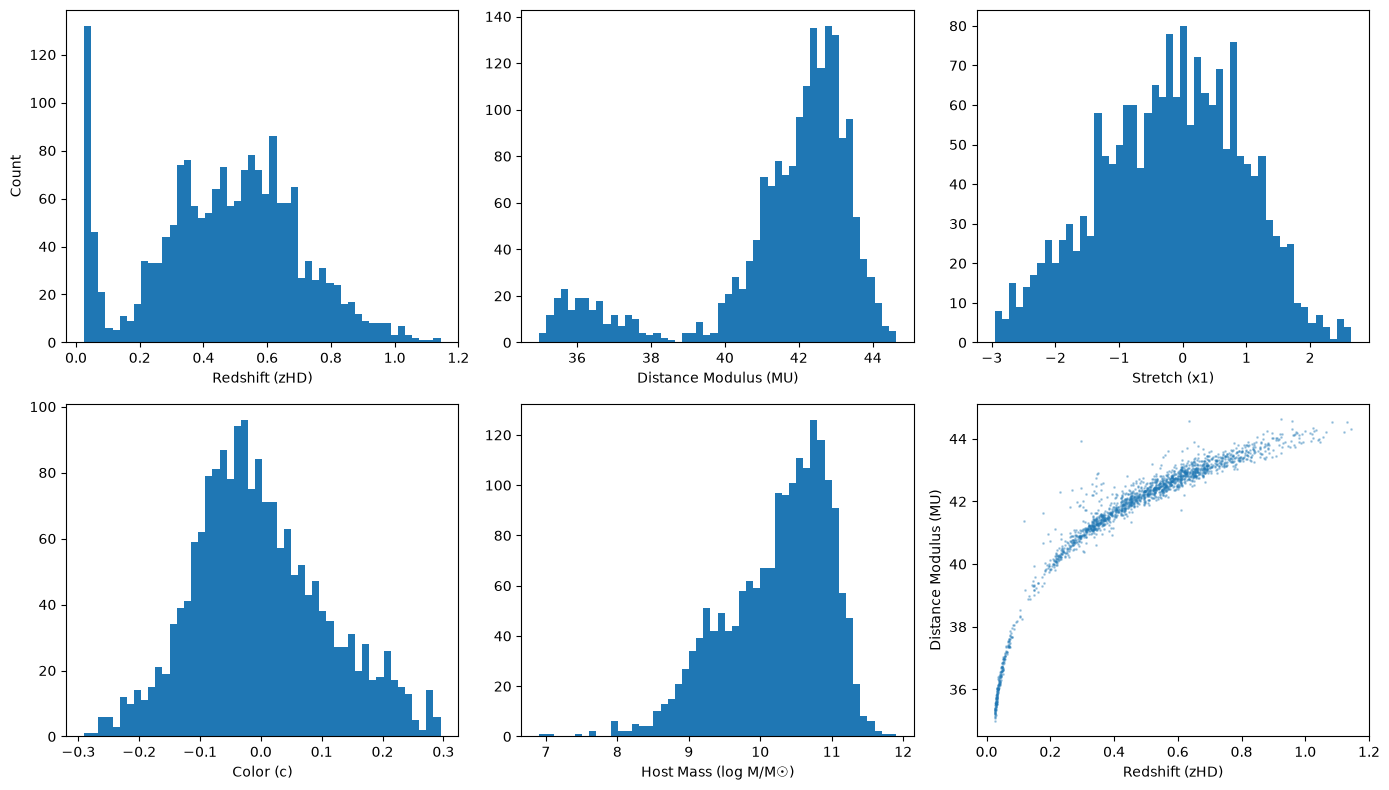

In [102]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].hist(df["zHD"], bins=50)
axes[0, 0].set_xlabel("Redshift (zHD)")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(df["MU"], bins=50)
axes[0, 1].set_xlabel("Distance Modulus (MU)")

axes[0, 2].hist(df["x1"].dropna(), bins=50)
axes[0, 2].set_xlabel("Stretch (x1)")

axes[1, 0].hist(df["c"].dropna(), bins=50)
axes[1, 0].set_xlabel("Color (c)")

mass = df["HOST_LOGMASS"].dropna()
axes[1, 1].hist(mass, bins=50)
axes[1, 1].set_xlabel("Host Mass (log M/M\u2609)")

good = df["zHD"] > 0.01
axes[1, 2].scatter(df.loc[good, "zHD"], df.loc[good, "MU"], s=1, alpha=0.3)
axes[1, 2].set_xlabel("Redshift (zHD)")
axes[1, 2].set_ylabel("Distance Modulus (MU)")

fig.tight_layout()
plt.show()

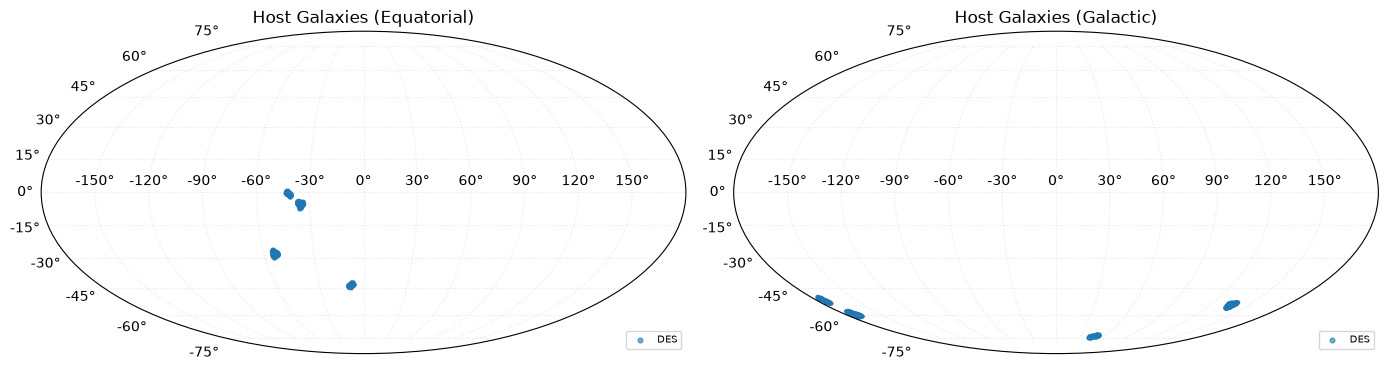

In [103]:
fig = plt.figure(figsize=(14, 6))
ax0 = plt.subplot(1, 2, 1, projection="mollweide")
mollweide_scatter(ax0, df_refined['HOST_RA'], df_refined['HOST_DEC'], df_refined['survey_name'],
                  'Host Galaxies (Equatorial)')

ax1 = plt.subplot(1, 2, 2, projection="mollweide")
mollweide_scatter(ax1, df_refined['l'], df_refined['b'], df_refined['survey_name'],
                  'Host Galaxies (Galactic)')
plt.tight_layout()
plt.show()

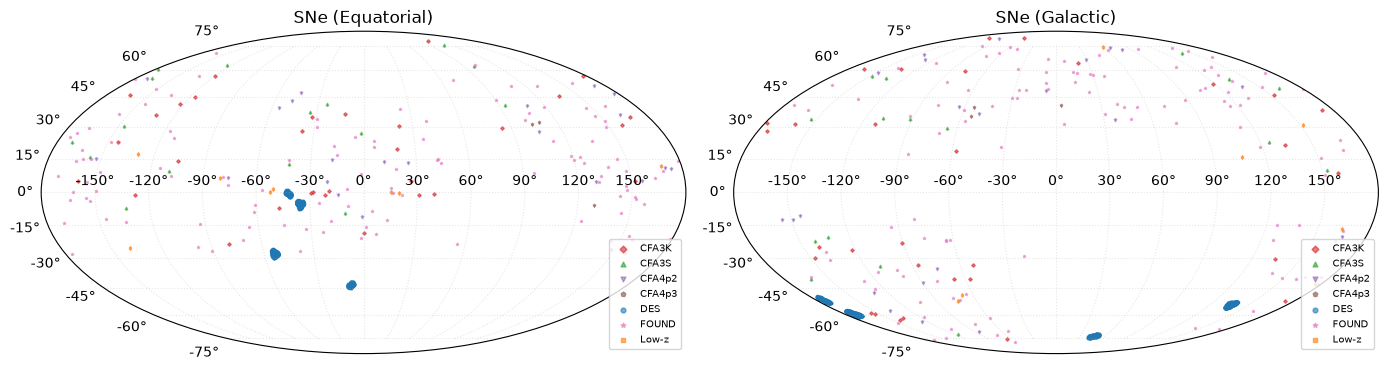

In [104]:
fig = plt.figure(figsize=(14, 6))
ax0 = plt.subplot(1, 2, 1, projection="mollweide")
mollweide_scatter(ax0, df['RA'], df['DEC'], df['survey_name'],
                  'SNe (Equatorial)')

ax1 = plt.subplot(1, 2, 2, projection="mollweide")
mollweide_scatter(ax1, df['l'], df['b'], df['survey_name'],
                  'SNe (Galactic)')
plt.tight_layout()
plt.show()

In [105]:
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
#                                gridspec_kw={"height_ratios": [3, 1]})

# good = df["zHD"] > 0.01
# z = df.loc[good, "zHD"].values
# mu = df.loc[good, "MU"].values
# muerr = df.loc[good, "MUERR"].values
# names = df.loc[good, "survey_name"].values

# for sn in sorted(survey_styles):
#     mask = names == sn
#     if mask.sum() == 0: continue
#     sty = survey_styles[sn]
#     ax1.errorbar(z[mask], mu[mask], yerr=muerr[mask],
#                  fmt=sty["marker"], c=sty["color"], ms=2, alpha=0.5, label=sn, capsize=0)

# ax1.set_ylabel("Distance Modulus")
# ax1.legend(fontsize=7, markerscale=2)
# ax1.grid(True, alpha=0.3)

# # Simple LCDM fit for residuals
# from scipy.optimize import curve_fit
# c_light = 299792.458

# def lcdm_mu(z, M):
#     from scipy.integrate import quad
#     def E(zp): return np.sqrt(0.3*(1+zp)**3 + 0.7)
#     dc = np.array([quad(E, 0, zi)[0] for zi in z])
#     dl = c_light * (1+z) * dc / 100  # H0=100 km/s/Mpc
#     return 5 * np.log10(dl) + 25 + M

# try:
#     popt, _ = curve_fit(lcdm_mu, z, mu, p0=[0], sigma=muerr, maxfev=2000)
#     mu_model = lcdm_mu(z, *popt)
#     residuals = mu - mu_model
#     ax2.scatter(z, residuals, s=2, alpha=0.4, c="k")
#     ax2.axhline(0, c="r", ls="--", lw=0.5)
#     ax2.set_xlabel("Redshift (zHD)")
#     ax2.set_ylabel("Residual (MU)")
#     ax2.grid(True, alpha=0.3)
#     print(f"LCDM fit: M = {popt[0]:.3f}")
# except Exception as e:
#     ax2.text(0.5, 0.5, f"Fit failed: {e}", transform=ax2.transAxes)

# fig.tight_layout()
# plt.show()

In [106]:
# fig, axes = plt.subplots(2, 4, figsize=(16, 8))
# axes = axes.ravel()

# surveys = sorted(df["survey_name"].unique())
# colors = plt.cm.tab10(np.linspace(0, 1, len(surveys)))

# for i, (ax, sn) in enumerate(zip(axes[:len(surveys)], surveys)):
#     sub = df[df["survey_name"] == sn]
#     ax.hist(sub["zHD"], bins=30, color=colors[i], alpha=0.7)
#     ax.set_title(f"{sn} (N={len(sub)})", fontsize=10)
#     ax.set_xlabel("z")

# for ax in axes[len(surveys):]:
#     ax.set_visible(False)

# fig.tight_layout()
# plt.show()

In [107]:
print("=" * 45)
print("DES-SN5YR Summary")
print("=" * 45)
print(f"  Total SNe:          {len(df)}")
print(f"  Unique CIDs:        {df["CID"].nunique()}")
print(f"  Surveys:            {df["IDSURVEY"].nunique()}")
print(f"  Redshift range:     {df["zHD"].min():.4f} - {df["zHD"].max():.4f}")
print(f"  Distance modulus:   {df["MU"].mean():.2f} +/- {df["MU"].std():.2f}")
print(f"  Host mass avail:    {df["HOST_LOGMASS"].notna().sum()} / {len(df)}")
print(f"  SN RA/DEC from FITS:{df["RA"].notna().sum()} / {len(df)}")
print(f"  Host coords:        {len(df_refined)} / {len(df)}")

DES-SN5YR Summary
  Total SNe:          1820
  Unique CIDs:        1820
  Surveys:            7
  Redshift range:     0.0251 - 1.1442
  Distance modulus:   41.57 +/- 2.11
  Host mass avail:    1820 / 1820
  SN RA/DEC from FITS:1820 / 1820
  Host coords:        1623 / 1820
